In [28]:
import numpy as np
from astropy.io import fits
from pathlib import Path
import os

In [29]:
# Opening the image file data and looking at the header to look for :
hdu_list = fits.open('/Users/applestore/exo-observe/Data/GJ-1214b/raw_data/d-UW32R103.fits')
#hdu_list = fits.open('/Users/applestore/Downloads/wcs.fits')

hdu = hdu_list[0]
hdu.header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy and
COMMENT   Astrophysics Supplement Series v44/p363, v44/p371, v73/p359, v73/p365.
COMMENT   Contact the NASA Science Office of Standards and Technology for the   
COMMENT   FITS Definition document #100 and other FITS information.             
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
NEXTEND =                    4 / Number of extensions                           
FILENAME= '/home2/images/CHILE/2010-04-28/science.316' / Original host filename 
OBJECT  = 'GJ1214  '        

In [30]:
# Opening the image file data and looking at the header to look for :
hdu_listt = fits.open('/Users/applestore/exo-observe/Data/HAT-32b/raw_data/d4466637UW32R004.fit')
#hdu_list = fits.open('/Users/applestore/Downloads/wcs.fits')

hdu = hdu_listt[0]
hdu.header

SIMPLE  =                    T / NORMAL FITS IMAGE                              
BITPIX  =                   16 / DATA PRECISION                                 
NAXIS   =                    2 / NUMBER OF IMAGE DIMENSIONS                     
NAXIS1  =                  512 / NUMBER OF COLUMNS                              
NAXIS2  =                  512 / NUMBER OF ROWS                                 
BLOCKED =                    T / CHECK FOR POSSIBLE BLOCKING                    
CRVAL1  =                 1116 / COLUMN ORIGIN                                  
CRVAL2  =                 1870 / ROW ORIGIN                                     
CDELT1  =                    1 / COLUMN BINNING                                 
CDELT2  =                    1 / ROW BINNING                                    
IMNAME  = '              UW32' / OBSERVATION SEQUENCE NAME                      
DATE-OBS= '          10/12/13' / DATE OF START OF OBSERVATION                   
TIME    = '        12:10:40.

In [ ]:
# Modify contents inside a header 

reduced_path = Path('/Users/applestore/exo-observe/Data/GJ-1214b/raw_data')

# Extract the filenames of the image files
image_files = [os.path.join(reduced_path, filename) for filename in os.listdir(reduced_path) if filename.endswith(".fits")]

# For when the entries aren'r present in the header:

#for image_file in image_files:
#    hdulist = fits.open(image_file, mode='update')  # Open the file for modification
#    header = hdulist[0].header  # Access the header of the primary HDU
#    header['IMG_TYP'] = 'dark'  # Add the keyword with the value 'adu'

#    if 'CRVAL1' not in header:  # Check if the keyword already exists
#        header['CRVAL1'] = 1050  # Add the keyword with the value 'adu'
#    if 'CRVAL2' not in header:  # Check if the keyword already exists
#        header['CRVAL2'] = 1810  # Add the keyword with the value 'adu'

# For when we do have the enteries but want to update their value:

for image_file in image_files:
    hdulist = fits.open(image_file, mode='update')  # Open the file for modification
    header = hdulist[0].header  # Access the header of the primary HDU
#    header['IMG_TYP'] = 'dark'  # Add the keyword with the value 'adu'

    header['CRVAL1'] = 1050  # Update the value of CRVAL1
    header['CRVAL2'] = 1810  # Update the value of CRVAL2

    
    hdulist.flush()  # Write changes to disk
    hdulist.close()  # Close the file

In [6]:
# Finding files with a specific value for one of header entries in a folder:
exraw_path = Path('/Users/applestore/exo-observe/Data/GJ-1214b/raw_data')
from ccdproc import ImageFileCollection
import pprint

ex1_images_raw = ImageFileCollection(exraw_path)
dark_files = ex1_images_raw.summary[ex1_images_raw.summary['obstype'] == 'DARK']['file']
pprint.pprint(dark_files)


<MaskedColumn name='file' dtype='str18' length=0>



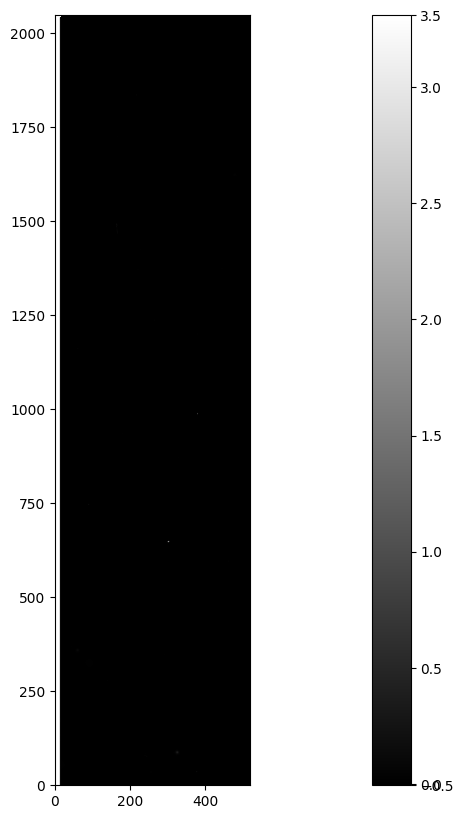